In [1]:
%pip install kagglehub
%pip install pandas
%pip install scipy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas
df = pandas.read_csv("dataset/games.csv")

SECTION: EXPLORATORY DATA ANALYSIS SECTION (EDA)

In [3]:
# EDA: Understanding the features of the dataset
print(df.head())
print(df.shape)
df.isnull().sum()

         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   

  increment_code       white_id  white_rating      black_id  black_rating  \
0           15+2       bourgris          1500          a-00          1191   
1           5+10           a-00          1322     skinnerua          1261   
2           5+10         ischia          1496          a-00          1500   
3           20+0  daniamurashov          1439  adivanov2009          1454   
4           30+3      nik221107          1523  adivanov2009          1469   

                                               moves opening_e

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

In [4]:
#EDA: Visualizing the data
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

output_dir = "EDA"
os.makedirs(output_dir, exist_ok=True)

# Features to plot a scatterplot for
feature_plot = ['rated', 'created_at', 'last_move_at', 'turns', 'increment_code', 'black_rating', 'opening_ply']

# Scatterplot
for i in range(1, len(df.columns)):
    if df.columns[i] in feature_plot:
        filename = f'{df.columns[i]}_vs_white_rating_scatter'
        filepath = os.path.join(output_dir, filename)

        plt.figure(figsize=(12, 6))
        plt.scatter(df[df.columns[i]], df['white_rating'], alpha=0.3)
        plt.ylabel('WHITE RATING')
        plt.xlabel(df.columns[i].upper())
        plt.savefig(filepath)
        plt.close()

# Features to calculate pcc for
feature_pcc = ['rated', 'created_at', 'last_move_at', 'turns', 'black_rating', 'opening_ply']

# Format of dictionary will be:   Key = Feature | Value = [correlation coefficient, p_value]
pcc_dict = {}
# Pearson Correlation Coefficient
for column in df.columns:
    if column in feature_pcc:
        corr_co, p_value = pearsonr(df[column], df['white_rating'])
        pcc_dict[column] = (corr_co, p_value)

# Store values in a txt file
with open("EDA/pcc_values.txt", 'w') as file:
    json.dump(pcc_dict, file, indent=4)

In [5]:
# EDA: Examining increment_code feature
# Seeing if there is a relationship between increment_code and white_rating,
# but ensuring that the opening sample size is large enough to be meaningful
eco_stats = df.groupby("opening_eco")["white_rating"].agg(["mean","count"])
eco_stats_filtered = eco_stats[eco_stats["count"] > 50]
eco_stats_filtered.sort_values("mean", ascending=False).head(20)

,mean,count
opening_eco,,
B90,1772.376238,101
B13,1761.388235,85
E20,1758.454545,77
E61,1744.423729,59
A46,1741.240506,79
A15,1737.250000,60
D35,1733.069444,72
B22,1726.510638,94
B40,1713.844961,129


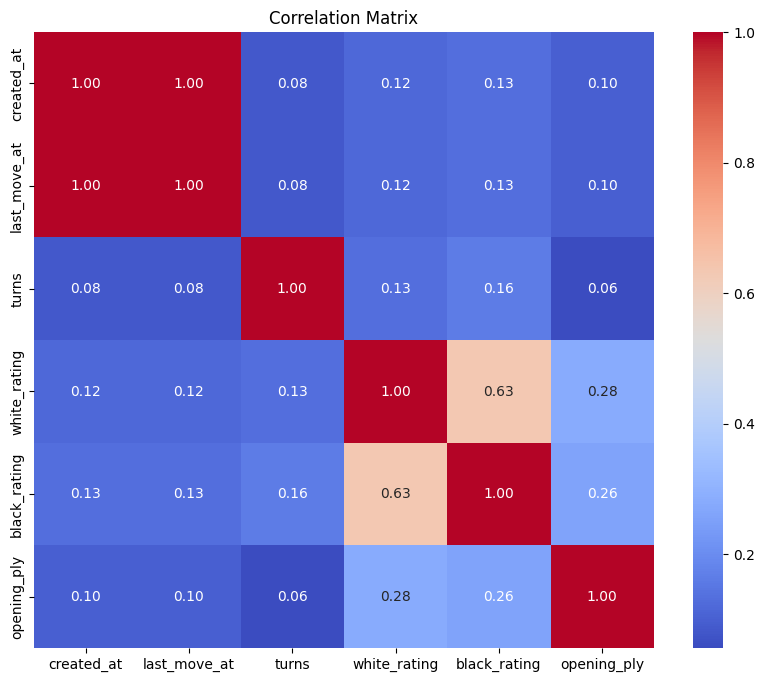

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA: Correlation Matrix
numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

SECTION: FEATURE ENGINEERING 

One thing to note is that we will be find commonly played advanced/beginner moves (e.g., pawn pushes, captures, etc.) and add them as features in the dataset. 

In [7]:
import pandas as pd

def move_features(row):
    moves = row["moves"].split()
    turns = row["turns"] / 2

    white_moves = moves[0::2]
    black_moves = moves[1::2]

    white_first5 = white_moves[:5]
    black_first5 = black_moves[:5]

    white_first10 = white_moves[:10]
    black_first10 = black_moves[:10]

    # Whole game counts
    white_checks = sum("+" in m for m in white_moves)
    black_checks = sum("+" in m for m in black_moves)

    white_captures = sum("x" in m for m in white_moves)
    black_captures = sum("x" in m for m in black_moves)

    # Early queen moves
    white_queen = sum(m.startswith("Q") for m in white_first5)
    black_queen = sum(m.startswith("Q") for m in black_first5)

    # Early castles
    white_castle = sum(m in ["O-O", "O-O-O"] for m in white_first5)
    black_castle = sum(m in ["O-O", "O-O-O"] for m in black_first5)

    # Early pawn pushes
    white_pawns = sum(m[0] in "abcdefgh" for m in white_first10)
    black_pawns = sum(m[0] in "abcdefgh" for m in black_first10)

    return pd.Series({
        "white_check_rate": white_checks / turns,
        "black_check_rate": black_checks / turns,

        "white_capture_rate": white_captures / turns,
        "black_capture_rate": black_captures / turns,

        "white_early_queen_rate": white_queen / 5,
        "black_early_queen_rate": black_queen / 5,

        "white_early_castle": white_castle,
        "black_early_castle": black_castle,

        "white_early_pawn_rate": white_pawns / 10,
        "black_early_pawn_rate": black_pawns / 10
    })


df[[
    "white_check_rate",
    "black_check_rate",
    "white_capture_rate",
    "black_capture_rate",
    "white_early_queen_rate",
    "black_early_queen_rate",
    "white_early_castle_rate",
    "black_early_castle_rate",
    "white_early_pawn_rate",
    "black_early_pawn_rate"
]] = df.apply(move_features, axis=1)

In [8]:
# Feature engineering: dropping columns that won't be used for modeling, and data cleaning:
# Removing the benchmark elo score
df = df.drop(columns=[
    "id",
    "created_at",
    "last_move_at",
    "white_id",
    "black_id",
    "moves",
    "opening_name"
])

# Ended up being about 10% of the data, but the data points had no predictive power
df = df[(df['white_rating'] != 1500) & (df['black_rating'] != 1500)]

In [9]:
# Feature Engineering: One hot encoding opening, victory status, and winner. Split time incrememnt into base time and increment. Map rated to 1 and unrated to 0.

# Replace true and false if we haven't already
if (df['rated'].dtype == bool):
    mapping = {"rated": {True: 1, False: 0}}

    # Map the labels to values
    for col, m in mapping.items():
        df[col] = df[col].map(m)

# Make time increment from categorical to numerical
# Split increment_code into base_time and increment as integers
df[["base_time", "increment"]] = df["increment_code"].str.split("+", expand=True).astype(int)

# Drop original time control column
df = df.drop(columns=["increment_code"])

# One-hot encode categorical columns
one_hot_encoded = pd.get_dummies(
    df,
    columns=['victory_status', 'opening_eco', 'winner'],
    drop_first=False,  # safer to include all categories to avoid strings remaining
    dtype=int
)

# Save cleaned DataFrame
one_hot_encoded.to_csv('dataset/clean_games.csv', index=False)


In [10]:
# Feature Engineering: Ensuring new df structure
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

df_clean = pandas.read_csv("dataset/clean_games.csv")
print(df_clean.shape)
print(df_clean.loc[:, ~df_clean.columns.str.startswith("opening_eco")].head())


# EDA: scatterplot of new features.
# Note: we are plotting the new move features and opening_eco. Only a selection of
# opening eco are chosen. We based selection off of number of data points and mean
# elo. These are the chosen moves:

#   Opening_Eco         Mean Elo        Count
#   B90	                1772.376238	    101
#   B50	                1682.469027	    226
#   B30	                1673.700441	    227
#   A45	                1669.690476	    252
#   B01	                1542.589385	    716
#   C40	                1465.838565	    446
#   A00	                1429.743793	    1007
#   C20	                1384.703704	    675

output_dir = "EDA"
os.makedirs(output_dir, exist_ok=True)

# Features to plot a scatterplot for
feature_plot = [
    "white_check_rate",
    "white_capture_rate",
    "white_early_queen_rate",
    "white_early_castle_rate",
    "white_early_pawn_rate",
    "opening_eco_B90",
    "opening_eco_B50",
    "opening_eco_B30",
    "opening_eco_A45",
    "opening_eco_B01",
    "opening_eco_C40",
    "opening_eco_A00",
    "opening_eco_C20"
]

# Scatterplot
for i in range(1, len(df_clean.columns)):
    if df_clean.columns[i] in feature_plot:
        filename = f'{df_clean.columns[i]}_vs_white_rating_scatter'
        filepath = os.path.join(output_dir, filename)

        plt.figure(figsize=(12, 6))
        plt.scatter(df_clean[df_clean.columns[i]], df_clean['white_rating'], alpha=0.3)
        plt.ylabel('WHITE RATING')
        plt.xlabel(df_clean.columns[i].upper())
        plt.savefig(filepath)
        plt.close()

(18565, 387)
   rated  turns  white_rating  black_rating  opening_ply  white_check_rate  \
0      1     16          1322          1261            4          0.125000   
1      1     61          1439          1454            3          0.393443   
2      1     95          1523          1469            5          0.084211   
3      0      5          1250          1002            4          0.000000   
4      1     33          1520          1423           10          0.121212   

   black_check_rate  white_capture_rate  black_capture_rate  \
0          0.125000            0.250000            0.375000   
1          0.000000            0.327869            0.131148   
2          0.084211            0.294737            0.210526   
3          0.000000            0.000000            0.000000   
4          0.121212            0.303030            0.303030   

   white_early_queen_rate  ...  black_early_pawn_rate  base_time  increment  \
0                     0.0  ...                    0.3       

Look at C20 and B50 scatterplots.

<Figure size 1200x1000 with 0 Axes>

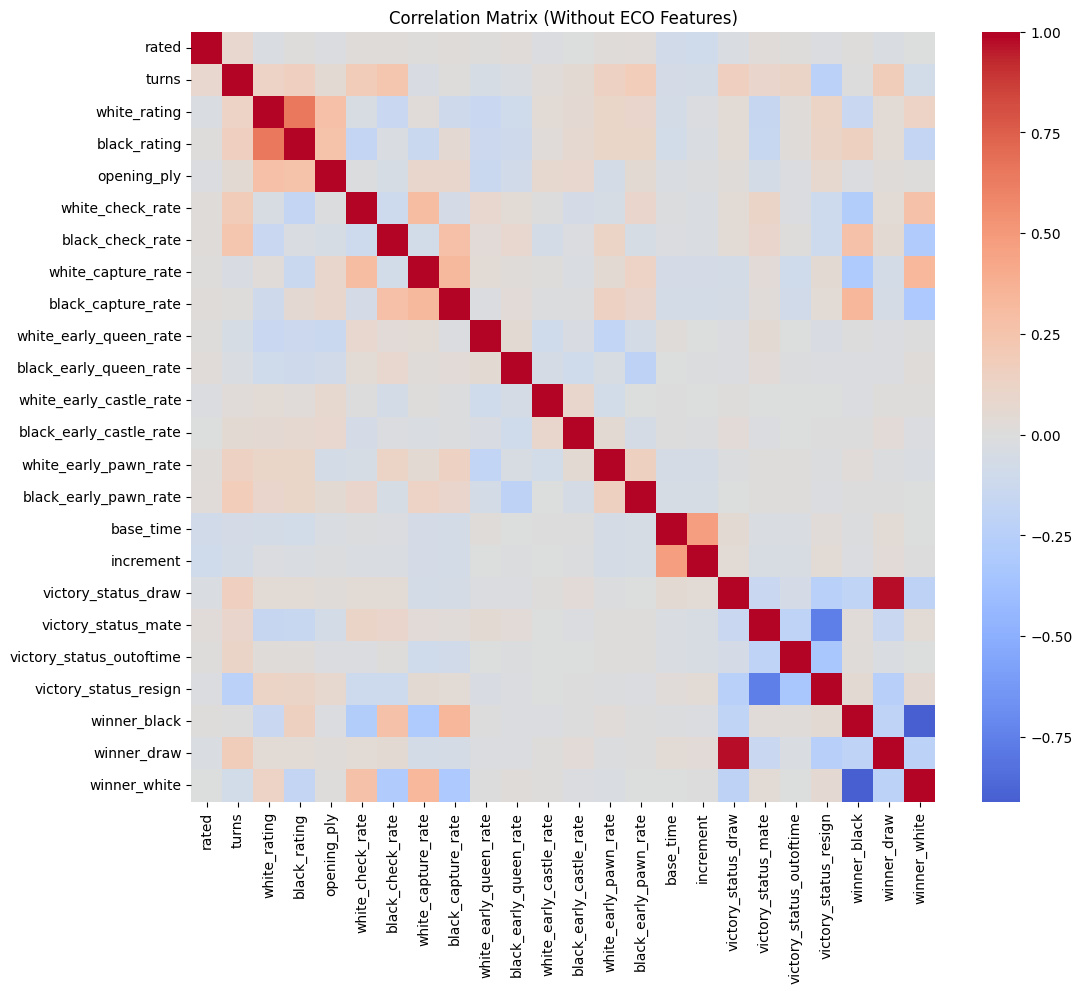

In [11]:
# Feature Engineering: Correlation Matrix with new features (No ECO)
df_corr = df_clean.loc[:, ~df_clean.columns.str.startswith("opening_eco")]
corr_matrix = df_corr.corr()
plt.figure(figsize=(12,10))
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix (Without ECO Features)")
plt.show()

SECTION: MODELLING

In [12]:
# Modeling: Linear Regression on full df
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Features and target
y = df_clean['white_rating']
X = df_clean.drop(columns=['white_rating'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear regression with 3-fold CV
model = LinearRegression()
cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='r2')
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

# Fit on full training set and evaluate test R2
model.fit(X_train, y_train)
r2_test = model.score(X_test, y_test)
print("Test R2:", r2_test)


# AI SAYS THAT p-value SHRINKS THE MORE ROWS THAT WE HAVE. 
# Statsmodels for p-values (add constant)
X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()
results = pd.DataFrame({
    "feature": model_sm.params.index,
    "coefficient": model_sm.params.values,
    "p_value": model_sm.pvalues.values
}).sort_values("p_value")

print(results.head(20))  # top 20 features by significance

CV R2 scores: [0.5278824  0.51677812 0.51839215]
Mean CV R2: 0.5210175585165028
Test R2: 0.5308565119122342
                      feature  coefficient        p_value
3                black_rating     0.624568   0.000000e+00
0                       const   345.556712  1.056624e-222
8          black_capture_rate  -434.363129   3.320903e-81
386              winner_white   185.984643   1.122731e-66
7          white_capture_rate   321.330065   2.466690e-47
4                 opening_ply    15.625931   6.533829e-35
20      victory_status_resign    79.682191   7.692614e-18
384              winner_black    86.616910   1.158816e-15
2                       turns     0.403740   3.787160e-15
19   victory_status_outoftime    69.841792   3.301566e-14
6            black_check_rate  -156.589365   1.822416e-12
217           opening_eco_C46   -95.685963   5.680534e-11
13      white_early_pawn_rate    76.452157   2.151464e-10
17        victory_status_draw   147.163015   7.170514e-10
221           opening_

SECTION: PCA AND THEN MORE MODELLING

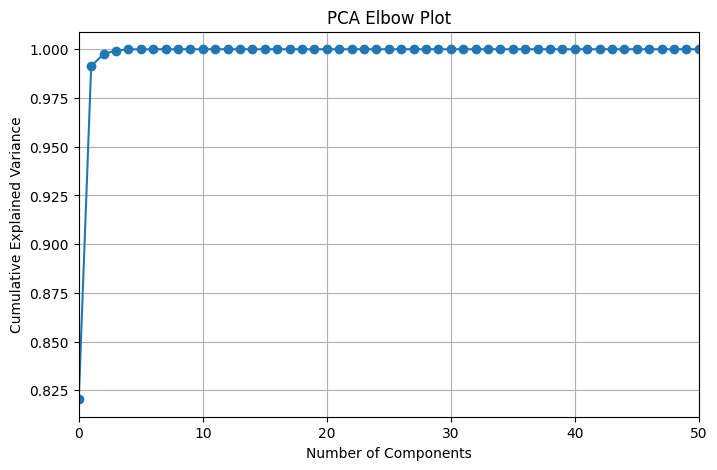

In [18]:
# PCA
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_clean)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(len(explained_variance)), cumulative_variance, marker='o')
plt.xlim(0, 50)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Elbow Plot")
plt.grid(True)
plt.show()